# Chapter 73 — Temperature, Greedy Decoding, and Top-K Sampling

Chapter 72 sampled each next character from the model's probability distribution.

This chapter compares three ways to turn the same final-position logits into a token choice.

## Learning goals

By the end of this chapter, you will be able to:

- explain greedy decoding and why it can become repetitive;
- explain how temperature sharpens or flattens probabilities;
- implement exact top-k filtering;
- combine temperature with top-k sampling;
- generate from one prompt with controlled strategy settings;
- compare temperature distributions in a plot; and
- distinguish validation loss from generated sample quality.

## Scores and decisions

A **logit** is one raw model score before softmax.

A **decoding strategy** turns final-position logits into one next-token choice.

**Greedy decoding** deterministically chooses the largest logit.

**Temperature sampling** divides logits by a positive temperature before softmax and random sampling.

**Top-k sampling** randomly chooses among only the `k` tokens with the largest adjusted logits.

These strategies do not change model parameters or the logits produced for a fixed context.

## Recreate the trained character model

A clean notebook kernel cannot inherit Chapter 71's live model object.

The next three cells compactly recreate the same embedded data, architecture, and deterministic 1,000-update training run.

The remainder of the notebook changes only decoding.

In [1]:
import torch

device = "cpu"
model_config = {
    "context_length": 64,
    "embedding_dimension": 64,
    "number_of_attention_heads": 4,
    "number_of_transformer_blocks": 2,
    "dropout_rate": 0.1,
    "batch_size": 16,
    "learning_rate": 0.0003,
    "training_steps": 1000,
}

public_domain_text = """
Alice was beginning to get very tired of sitting by her sister on the bank,
and of having nothing to do. Once or twice she had peeped into the book her
sister was reading, but it had no pictures or conversations in it, and what is
the use of a book, thought Alice, without pictures or conversation?

So she was considering in her own mind, as well as she could, for the hot day
made her feel very sleepy and stupid, whether the pleasure of making a daisy
chain would be worth the trouble of getting up and picking the daisies, when
suddenly a white rabbit with pink eyes ran close by her.

There was nothing so very remarkable in that; nor did Alice think it so very
much out of the way to hear the rabbit say to itself, Oh dear! Oh dear! I shall
be too late! But when the rabbit actually took a watch out of its waistcoat
pocket, and looked at it, and then hurried on, Alice started to her feet.

The rabbit-hole went straight on like a tunnel for some way, and then dipped
suddenly down, so suddenly that Alice had not a moment to think about stopping
herself before she found herself falling down what seemed to be a very deep
well.

Either the well was very deep, or she fell very slowly, for she had plenty of
time as she went down to look about her and to wonder what was going to happen
next.
""".strip()

split_index = int(0.85 * len(public_domain_text))
training_text = (public_domain_text[:split_index] + "\n\n") * 20
validation_text = (public_domain_text[split_index:] + "\n\n") * 20
characters = sorted(set(public_domain_text + "\n"))
character_to_id = {
    character: character_id for character_id, character in enumerate(characters)
}
id_to_character = {
    character_id: character for character, character_id in character_to_id.items()
}


def encode_text(text: str, token_to_id: dict[str, int]) -> list[int]:
    return [token_to_id[character] for character in text]


def decode_token_ids(token_ids: list[int], id_to_token: dict[int, str]) -> str:
    return "".join(id_to_token[token_id] for token_id in token_ids)


training_token_ids = torch.tensor(
    encode_text(training_text, character_to_id), dtype=torch.long, device=device
)
validation_token_ids = torch.tensor(
    encode_text(validation_text, character_to_id), dtype=torch.long, device=device
)

print("device:", device)
print("vocabulary size:", len(characters))
print("training tokens:", training_token_ids.numel())
print("validation tokens:", validation_token_ids.numel())

device: cpu
vocabulary size: 38
training tokens: 22120
validation tokens: 3940


The architecture matches Chapter 71's combined-head pre-normalized transformer.

Its output logits have shape `[batch, context, vocabulary]`.

In [2]:
import math


class MultiHeadCausalSelfAttention(torch.nn.Module):
    """Compute causal multi-head attention with combined projections."""

    embedding_dimension: int
    number_of_attention_heads: int
    head_size: int
    context_length: int
    query_projection: torch.nn.Linear
    key_projection: torch.nn.Linear
    value_projection: torch.nn.Linear
    attention_dropout: torch.nn.Dropout
    output_projection: torch.nn.Linear
    output_dropout: torch.nn.Dropout
    causal_mask: torch.Tensor

    def __init__(
        self,
        embedding_dimension: int,
        number_of_attention_heads: int,
        context_length: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        if embedding_dimension % number_of_attention_heads != 0:
            raise ValueError(
                "embedding dimension must divide evenly by the head count."
            )

        self.embedding_dimension = embedding_dimension
        self.number_of_attention_heads = number_of_attention_heads
        self.head_size = embedding_dimension // number_of_attention_heads
        self.context_length = context_length
        self.query_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.key_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.value_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.attention_dropout = torch.nn.Dropout(dropout_rate)
        self.output_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension
        )
        self.output_dropout = torch.nn.Dropout(dropout_rate)
        self.register_buffer(
            "causal_mask",
            torch.tril(
                torch.ones(1, 1, context_length, context_length, dtype=torch.bool)
            ),
        )

    def _split_heads(self, vectors: torch.Tensor) -> torch.Tensor:
        batch_size, current_context_length, _ = vectors.shape
        return vectors.reshape(
            batch_size,
            current_context_length,
            self.number_of_attention_heads,
            self.head_size,
        ).transpose(1, 2)

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        batch_size, current_context_length, _ = input_values.shape
        queries = self._split_heads(self.query_projection(input_values))
        keys = self._split_heads(self.key_projection(input_values))
        values = self._split_heads(self.value_projection(input_values))
        scaled_scores = (queries @ keys.transpose(-2, -1)) / math.sqrt(self.head_size)
        allowed = self.causal_mask[
            :, :, :current_context_length, :current_context_length
        ]
        weights = torch.softmax(
            scaled_scores.masked_fill(~allowed, float("-inf")), dim=-1
        )
        attended_values = self.attention_dropout(weights) @ values
        concatenated = attended_values.transpose(1, 2).reshape(
            batch_size, current_context_length, self.embedding_dimension
        )
        return self.output_dropout(self.output_projection(concatenated))


class PositionWiseFeedForward(torch.nn.Module):
    """Apply a shared C-to-4C-to-C network at every position."""

    network: torch.nn.Sequential

    def __init__(self, embedding_dimension: int, dropout_rate: float) -> None:
        super().__init__()
        self.network = torch.nn.Sequential(
            torch.nn.Linear(embedding_dimension, 4 * embedding_dimension),
            torch.nn.ReLU(),
            torch.nn.Linear(4 * embedding_dimension, embedding_dimension),
            torch.nn.Dropout(dropout_rate),
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        return self.network(input_values)


class TransformerBlock(torch.nn.Module):
    """Apply one pre-normalized causal transformer block."""

    first_layer_norm: torch.nn.LayerNorm
    attention: MultiHeadCausalSelfAttention
    second_layer_norm: torch.nn.LayerNorm
    feedforward: PositionWiseFeedForward

    def __init__(
        self,
        embedding_dimension: int,
        number_of_attention_heads: int,
        context_length: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        self.first_layer_norm = torch.nn.LayerNorm(embedding_dimension)
        self.attention = MultiHeadCausalSelfAttention(
            embedding_dimension,
            number_of_attention_heads,
            context_length,
            dropout_rate,
        )
        self.second_layer_norm = torch.nn.LayerNorm(embedding_dimension)
        self.feedforward = PositionWiseFeedForward(embedding_dimension, dropout_rate)

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        attention_change = self.attention(self.first_layer_norm(input_values))
        values_after_attention = input_values + attention_change
        feedforward_change = self.feedforward(
            self.second_layer_norm(values_after_attention)
        )
        return values_after_attention + feedforward_change


class TinyGPT(torch.nn.Module):
    """Map character ID sequences to next-character logits and loss."""

    vocabulary_size: int
    context_length: int
    token_embedding_table: torch.nn.Embedding
    position_embedding_table: torch.nn.Embedding
    embedding_dropout: torch.nn.Dropout
    transformer_blocks: torch.nn.ModuleList
    final_layer_norm: torch.nn.LayerNorm
    output_layer: torch.nn.Linear

    def __init__(
        self,
        vocabulary_size: int,
        context_length: int,
        embedding_dimension: int,
        number_of_attention_heads: int,
        number_of_transformer_blocks: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        self.vocabulary_size = vocabulary_size
        self.context_length = context_length
        self.token_embedding_table = torch.nn.Embedding(
            vocabulary_size, embedding_dimension
        )
        self.position_embedding_table = torch.nn.Embedding(
            context_length, embedding_dimension
        )
        self.embedding_dropout = torch.nn.Dropout(dropout_rate)
        self.transformer_blocks = torch.nn.ModuleList(
            [
                TransformerBlock(
                    embedding_dimension,
                    number_of_attention_heads,
                    context_length,
                    dropout_rate,
                )
                for _ in range(number_of_transformer_blocks)
            ]
        )
        self.final_layer_norm = torch.nn.LayerNorm(embedding_dimension)
        self.output_layer = torch.nn.Linear(embedding_dimension, vocabulary_size)

    def forward(
        self,
        input_token_ids: torch.Tensor,
        target_token_ids: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor | None]:
        if input_token_ids.ndim != 2:
            raise ValueError("input IDs must have shape [batch, context].")

        current_context_length = input_token_ids.shape[1]
        if current_context_length < 1:
            raise ValueError("input context cannot be empty.")
        if current_context_length > self.context_length:
            raise ValueError("input exceeds the model context length.")

        token_embeddings = self.token_embedding_table(input_token_ids)
        position_ids = torch.arange(
            current_context_length, device=input_token_ids.device
        )
        current_values = self.embedding_dropout(
            token_embeddings + self.position_embedding_table(position_ids)
        )
        for block in self.transformer_blocks:
            current_values = block(current_values)

        vocabulary_logits = self.output_layer(self.final_layer_norm(current_values))
        loss = None
        if target_token_ids is not None:
            if target_token_ids.shape != input_token_ids.shape:
                raise ValueError("targets must have the same shape as inputs.")
            loss = torch.nn.functional.cross_entropy(
                vocabulary_logits.reshape(-1, self.vocabulary_size),
                target_token_ids.reshape(-1),
            )
        return vocabulary_logits, loss

Training uses separate seeded batch randomness and prints a few checkpoints.

A fixed held-out batch then provides one validation loss that remains unchanged by every later decoding strategy.

In [3]:
def get_gpt_batch(
    token_ids: torch.Tensor,
    batch_size: int,
    context_length: int,
    generator: torch.Generator,
) -> tuple[torch.Tensor, torch.Tensor]:
    number_of_valid_starts = token_ids.numel() - context_length
    start_indexes = torch.randint(
        0,
        number_of_valid_starts,
        (batch_size,),
        generator=generator,
        device=token_ids.device,
    )
    offsets = torch.arange(context_length, device=token_ids.device)
    indexes = start_indexes[:, None] + offsets[None, :]
    return token_ids[indexes], token_ids[indexes + 1]


torch.manual_seed(71)
model = TinyGPT(
    vocabulary_size=len(characters),
    context_length=model_config["context_length"],
    embedding_dimension=model_config["embedding_dimension"],
    number_of_attention_heads=model_config["number_of_attention_heads"],
    number_of_transformer_blocks=model_config["number_of_transformer_blocks"],
    dropout_rate=model_config["dropout_rate"],
).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=model_config["learning_rate"])
training_generator = torch.Generator(device=device).manual_seed(7103)
model.train()

for step in range(1, model_config["training_steps"] + 1):
    input_batch, target_batch = get_gpt_batch(
        training_token_ids,
        batch_size=model_config["batch_size"],
        context_length=model_config["context_length"],
        generator=training_generator,
    )
    _, loss = model(input_batch, target_batch)
    if loss is None:
        raise RuntimeError("training requires targets.")
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    if step in {1, 250, 500, 750, 1000}:
        print(f"step {step:4}: batch loss {loss.item():.4f}")

validation_generator = torch.Generator(device=device).manual_seed(7300)
validation_input, validation_target = get_gpt_batch(
    validation_token_ids,
    batch_size=16,
    context_length=model.context_length,
    generator=validation_generator,
)
model.eval()
with torch.no_grad():
    _, validation_loss = model(validation_input, validation_target)

print("fixed validation loss:", validation_loss.item())

step    1: batch loss 3.8101


step  250: batch loss 2.3531


step  500: batch loss 2.1988


step  750: batch loss 2.0458


step 1000: batch loss 1.9439
fixed validation loss: 2.3239660263061523


## Start with a toy logit vector

A five-token example makes each strategy visible before we use the full character vocabulary.

The toy logits are invented and are not outputs from the trained model.

In [4]:
toy_tokens = ["a", "b", "c", "d", " "]
toy_logits = torch.tensor([4.0, 2.0, 1.0, -1.0, 3.0], device=device)
toy_probabilities = torch.softmax(toy_logits, dim=-1)

print("token | logit | probability")
print("-" * 29)
for token, logit, probability in zip(
    toy_tokens,
    toy_logits.tolist(),
    toy_probabilities.tolist(),
    strict=True,
):
    print(f"{token!r:>5} | {logit:>5.1f} | {probability:.6f}")

print("probability sum:", toy_probabilities.sum().item())

token | logit | probability
-----------------------------
  'a' |   4.0 | 0.641133
  'b' |   2.0 | 0.086768
  'c' |   1.0 | 0.031920
  'd' |  -1.0 | 0.004320
  ' ' |   3.0 | 0.235860
probability sum: 1.0


## Greedy decoding

Greedy decoding uses `argmax` to choose the largest logit and does not sample.

It is deterministic for fixed logits.

Repeatedly taking the locally largest logit can enter a repetitive loop, although repetition is a possible behavior rather than a guarantee.

In [5]:
greedy_token_id = torch.argmax(toy_logits).item()

print("greedy token ID:", greedy_token_id)
print("greedy token:", repr(toy_tokens[greedy_token_id]))

greedy token ID: 0
greedy token: 'a'


## Temperature sampling

Temperature sampling computes `softmax(logits / temperature)` before drawing a token.

A positive temperature below `1` magnifies logit differences and sharpens the distribution.

A temperature above `1` reduces logit differences and flattens the distribution.

Temperature must be positive, and temperature `1` leaves the original softmax distribution unchanged.

In [6]:
def probabilities_at_temperature(
    logits: torch.Tensor, temperature: float
) -> torch.Tensor:
    if temperature <= 0:
        raise ValueError("temperature must be positive.")
    return torch.softmax(logits / temperature, dim=-1)


temperatures = [0.5, 1.0, 1.5]
temperature_probabilities = {
    temperature: probabilities_at_temperature(toy_logits, temperature)
    for temperature in temperatures
}

print("token | T=0.5 | T=1.0 | T=1.5")
print("-" * 40)
for token_index, token in enumerate(toy_tokens):
    values = [
        temperature_probabilities[temperature][token_index].item()
        for temperature in temperatures
    ]
    print(f"{token!r:>5} | {values[0]:.5f} | {values[1]:.5f} | {values[2]:.5f}")

print()
for temperature in temperatures:
    top_probability = temperature_probabilities[temperature].max().item()
    print(f"T={temperature}: largest probability = {top_probability:.6f}")

token | T=0.5 | T=1.0 | T=1.5
----------------------------------------
  'a' | 0.86492 | 0.64113 | 0.51334
  'b' | 0.01584 | 0.08677 | 0.13532
  'c' | 0.00214 | 0.03192 | 0.06947
  'd' | 0.00004 | 0.00432 | 0.01831
  ' ' | 0.11705 | 0.23586 | 0.26356

T=0.5: largest probability = 0.864921
T=1.0: largest probability = 0.641133
T=1.5: largest probability = 0.513341


The grouped bar chart compares all three temperatures on the same axes.

A shared scale makes sharpening and flattening easier to compare than separate charts.

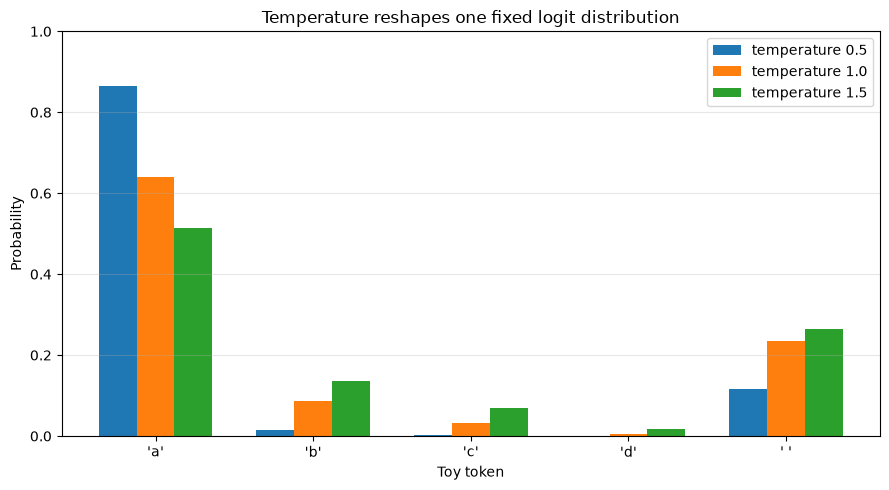

In [7]:
import matplotlib.pyplot as plt

x_positions = torch.arange(len(toy_tokens), dtype=torch.float32)
bar_width = 0.24
plt.figure(figsize=(9, 5))
for temperature_index, temperature in enumerate(temperatures):
    offset = (temperature_index - 1) * bar_width
    plt.bar(
        (x_positions + offset).tolist(),
        temperature_probabilities[temperature].tolist(),
        width=bar_width,
        label=f"temperature {temperature}",
    )

plt.xticks(x_positions.tolist(), [repr(token) for token in toy_tokens])
plt.xlabel("Toy token")
plt.ylabel("Probability")
plt.title("Temperature reshapes one fixed logit distribution")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Exact top-k filtering

Top-k filtering retains exactly the `k` selected indices and replaces every other logit with negative infinity.

Softmax then assigns zero probability to excluded tokens.

Filtering by a cutoff comparison is less precise because tied logits at the cutoff can retain more than `k` tokens.

In [8]:
def apply_top_k_filter(logits: torch.Tensor, top_k: int) -> torch.Tensor:
    vocabulary_size = logits.shape[-1]
    if not 1 <= top_k <= vocabulary_size:
        raise ValueError(
            f"top_k must be between 1 and vocabulary size {vocabulary_size}."
        )

    top_values, top_indices = torch.topk(logits, k=top_k, dim=-1)
    filtered_logits = torch.full_like(logits, float("-inf"))
    return filtered_logits.scatter(-1, top_indices, top_values)


filtered_toy_logits = apply_top_k_filter(toy_logits, top_k=2)
top_k_probabilities = torch.softmax(filtered_toy_logits, dim=-1)

print("token | original | filtered | probability")
print("-" * 46)
for token, original, filtered, probability in zip(
    toy_tokens,
    toy_logits.tolist(),
    filtered_toy_logits.tolist(),
    top_k_probabilities.tolist(),
    strict=True,
):
    print(f"{token!r:>5} | {original:>8.1f} | {filtered:>8.1f} | {probability:.6f}")

print("nonzero probabilities:", torch.count_nonzero(top_k_probabilities).item())

token | original | filtered | probability
----------------------------------------------
  'a' |      4.0 |      4.0 | 0.731059
  'b' |      2.0 |     -inf | 0.000000
  'c' |      1.0 |     -inf | 0.000000
  'd' |     -1.0 |     -inf | 0.000000
  ' ' |      3.0 |      3.0 | 0.268941
nonzero probabilities: 2


## Combine temperature and top-k

A common sampling order is to divide logits by temperature, retain the top `k`, apply softmax, and sample.

Positive temperature does not change logit ranking, so temperature changes probabilities among the retained tokens while top-k changes the allowed set.

In [9]:
def choose_next_token_id(
    final_position_logits: torch.Tensor,
    strategy: str,
    temperature: float = 1.0,
    top_k: int | None = None,
    generator: torch.Generator | None = None,
) -> torch.Tensor:
    if final_position_logits.ndim != 2:
        raise ValueError("logits must have shape [batch, vocabulary].")
    if strategy not in {"greedy", "sample"}:
        raise ValueError("strategy must be 'greedy' or 'sample'.")

    if strategy == "greedy":
        if temperature != 1.0 or top_k is not None:
            raise ValueError(
                "greedy decoding does not accept temperature or top_k changes."
            )
        return torch.argmax(final_position_logits, dim=-1, keepdim=True)

    if temperature <= 0:
        raise ValueError("temperature must be positive.")
    adjusted_logits = final_position_logits / temperature
    if top_k is not None:
        adjusted_logits = apply_top_k_filter(adjusted_logits, top_k)
    probabilities = torch.softmax(adjusted_logits, dim=-1)
    return torch.multinomial(probabilities, num_samples=1, generator=generator)


sampling_generator = torch.Generator(device=device).manual_seed(73)
combined_choice = choose_next_token_id(
    toy_logits.reshape(1, -1),
    strategy="sample",
    temperature=0.8,
    top_k=2,
    generator=sampling_generator,
)
print("combined temperature and top-k choice:", end=" ")
print(repr(toy_tokens[combined_choice.item()]))

combined temperature and top-k choice: 'a'


The chooser rejects invalid or ambiguous settings rather than silently changing their meaning.

These examples catch expected `ValueError` exceptions without failing notebook execution.

In [10]:
invalid_settings = [
    {"strategy": "sample", "temperature": 0.0},
    {"strategy": "sample", "top_k": 0},
    {"strategy": "greedy", "temperature": 0.5},
    {"strategy": "unknown"},
]

for settings in invalid_settings:
    try:
        choose_next_token_id(toy_logits.reshape(1, -1), **settings)
    except ValueError as error:
        print(f"{settings}: {error}")

{'strategy': 'sample', 'temperature': 0.0}: temperature must be positive.
{'strategy': 'sample', 'top_k': 0}: top_k must be between 1 and vocabulary size 5.
{'strategy': 'greedy', 'temperature': 0.5}: greedy decoding does not accept temperature or top_k changes.
{'strategy': 'unknown'}: strategy must be 'greedy' or 'sample'.


## Generate with a chosen strategy

The generation loop from Chapter 72 now delegates each token decision to `choose_next_token_id`.

Prompt validation, context cropping, evaluation mode, and mode restoration remain unchanged.

In [11]:
def validate_prompt(prompt: str, token_to_id: dict[str, int]) -> None:
    if not prompt:
        raise ValueError("prompt must not be empty.")
    unknown_characters = sorted(set(prompt) - set(token_to_id))
    if unknown_characters:
        raise ValueError(f"unknown prompt characters: {unknown_characters!r}")


@torch.no_grad()
def generate_text_with_strategy(
    model: TinyGPT,
    prompt: str,
    number_of_new_tokens: int,
    strategy: str,
    temperature: float = 1.0,
    top_k: int | None = None,
    sampling_seed: int = 73,
) -> str:
    if number_of_new_tokens < 0:
        raise ValueError("number_of_new_tokens must be nonnegative.")
    validate_prompt(prompt, character_to_id)

    generated_ids = torch.tensor(
        [encode_text(prompt, character_to_id)],
        dtype=torch.long,
        device=device,
    )
    generator = torch.Generator(device=device).manual_seed(sampling_seed)
    previous_training_mode = model.training
    model.eval()

    try:
        for _ in range(number_of_new_tokens):
            context_ids = generated_ids[:, -model.context_length :]
            vocabulary_logits, _ = model(context_ids)
            next_token_ids = choose_next_token_id(
                vocabulary_logits[:, -1, :],
                strategy=strategy,
                temperature=temperature,
                top_k=top_k,
                generator=generator,
            )
            generated_ids = torch.cat([generated_ids, next_token_ids], dim=1)
    finally:
        model.train(previous_training_mode)

    return decode_token_ids(generated_ids[0].tolist(), id_to_character)

## Compare strategies from one prompt

All stochastic strategies use seed `73`, so they begin from a controlled random stream while applying different distributions.

Greedy decoding is deterministic and does not consume the generator.

In [12]:
prompt = "Alice"
number_of_new_tokens = 160
strategy_settings = {
    "greedy": {"strategy": "greedy"},
    "temperature 0.5": {"strategy": "sample", "temperature": 0.5},
    "temperature 1.0": {"strategy": "sample", "temperature": 1.0},
    "temperature 1.5": {"strategy": "sample", "temperature": 1.5},
    "top-k 10": {
        "strategy": "sample",
        "temperature": 1.0,
        "top_k": 10,
    },
}
samples = {}
for strategy_name, settings in strategy_settings.items():
    samples[strategy_name] = generate_text_with_strategy(
        model,
        prompt=prompt,
        number_of_new_tokens=number_of_new_tokens,
        sampling_seed=73,
        **settings,
    )

for strategy_name, sample_text in samples.items():
    print("=" * 72)
    print(strategy_name)
    print("=" * 72)
    print(sample_text)
    print()

greedy
Alice the was to the to the the to to t to t to to to t to to to to to to thear thear thear thear theabo to to to t t to t too t to to theabito to to to theato to to

temperature 0.5
Alice to to the a at he t an touping watoor turr song the the sid t or ther othe cof ther tor tor he he o theto te the toto tothe t.
ito r o te to tithe hat too r sa

temperature 1.0
Alice of verr son ad hen Ohe ng ming watour trer son Aly ther sidasupe that otupicof thoy abbetur heerend t st tre t, pid, onvesema.
iaslind te Onding, hersenve rsll

temperature 1.5
Aliceng thurr son ae hin Ohick an Ond tiour trer ponSAlEe ?
! slepuddd ryBhedoupicofwSooy abbbtwanvkerendde st-tre t,; ad, onvis m .
iasuryertelOasyiaf herAlovofrsll

top-k 10
Alice of sher son ve sher foungha nnd d our trer son bby ther sle fofe r for tupicof whortheratur whe hedat st tre t,epid, onves wabichelink te tasing, hers, wo wher



## Inspect the trained model's next-character logits

The next cell uses one forward pass after `Alice` and compares its highest probabilities at three temperatures.

The ranking stays fixed because dividing by a positive temperature preserves order.

In [13]:
prompt_ids = torch.tensor(
    [encode_text(prompt, character_to_id)], dtype=torch.long, device=device
)
with torch.no_grad():
    prompt_logits, _ = model(prompt_ids)
final_prompt_logits = prompt_logits[0, -1]
top_logit_values, top_token_ids = torch.topk(final_prompt_logits, k=10)

print("rank | character | logit | P(T=.5) | P(T=1) | P(T=1.5)")
print("-" * 67)
real_probabilities = {
    temperature: probabilities_at_temperature(final_prompt_logits, temperature)
    for temperature in temperatures
}
for rank, (token_id, logit) in enumerate(
    zip(top_token_ids.tolist(), top_logit_values.tolist(), strict=True), start=1
):
    probability_values = [
        real_probabilities[temperature][token_id].item() for temperature in temperatures
    ]
    print(
        f"{rank:>4} | {id_to_character[token_id]!r:>9} | {logit:>5.2f} | "
        f"{probability_values[0]:>7.4f} | {probability_values[1]:>6.4f} | "
        f"{probability_values[2]:>8.4f}"
    )

rank | character | logit | P(T=.5) | P(T=1) | P(T=1.5)
-------------------------------------------------------------------
   1 |       ' ' |  5.31 |  0.9732 | 0.6927 |   0.4171
   2 |       'r' |  3.14 |  0.0128 | 0.0794 |   0.0984
   3 |       'n' |  2.82 |  0.0068 | 0.0579 |   0.0797
   4 |       't' |  2.46 |  0.0033 | 0.0401 |   0.0624
   5 |       'e' |  2.18 |  0.0019 | 0.0305 |   0.0520
   6 |       's' |  1.64 |  0.0006 | 0.0177 |   0.0361
   7 |       ',' |  1.42 |  0.0004 | 0.0142 |   0.0312
   8 |       'd' |  1.38 |  0.0004 | 0.0137 |   0.0305
   9 |       'g' |  1.09 |  0.0002 | 0.0102 |   0.0251
  10 |       'a' |  0.93 |  0.0002 | 0.0087 |   0.0225


## Validation loss and sample quality

Validation loss measures average next-token predictions on held-out real text.

Greedy, temperature, and top-k settings are applied only after the model produces logits, so the fixed validation loss above is identical for every strategy.

Generated sample quality also depends on prompt, random seed, sequence length, and decoding settings.

Lower validation loss usually indicates a better predictive model, but one generated sample is a noisy qualitative observation rather than an equivalent metric.

## Interpreting the comparison

- Greedy output may be stable but repetitive because no alternatives are explored.
- Temperature `0.5` concentrates probability on the model's leading choices.
- Temperature `1.0` samples from the unmodified softmax distribution.
- Temperature `1.5` gives lower-ranked characters more probability and may introduce more errors.
- Top-k `10` prevents every character outside the current ten highest logits from being selected.

There is no universally best setting because the appropriate balance depends on the model and the generation goal.

## Common mistakes

- Do not call greedy decoding a sampling method.
- Do not use a nonpositive temperature.
- Do not assume higher temperature improves quality.
- Do not assume greedy choices optimize the complete generated sequence.
- Do not silently clamp an invalid top-k setting.
- Do not use a cutoff comparison when exactly `k` retained indices are required.
- Do not let global randomness make strategy comparisons irreproducible.
- Do not infer model quality from one lucky or unlucky sample.

## Takeaways

Greedy decoding chooses the largest final-position logit with `argmax`.

Temperature sampling uses `softmax(logits / temperature)` to sharpen or flatten the distribution.

Top-k sampling assigns zero probability outside the `k` selected logit indices.

Temperature and top-k may be combined because one redistributes probability and the other restricts eligibility.

> Decoding settings can change visible samples substantially without changing model parameters, logits, or validation loss.

## What comes next

The next chapter can improve the model and training workflow rather than only changing decoding.

Natural next topics include larger datasets, checkpointing, learning-rate schedules, weight tying, and longer experiments.